In [61]:
# ===============================
# 1) Imports and Data Preparation
# ===============================
import pennylane as qml
from pennylane import numpy as np
import pandas as pd
import yfinance as yf
import networkx as nx
import matplotlib.pyplot as plt

# Import live assets to calculate daily returns and correlation matrix
assets = [
    "AAPL", "MSFT", "GOOGL", "AMZN", "NVDA", "META", "TSLA", "JPM", "V", "MA",
    "XOM", "CVX", "UNH", "HD", "PG", "KO", "PEP", "BAC", "PFE", "DIS",
    "NFLX", "INTC", "ADBE", "NKE", "T"
]

# Fetch adjusted close prices
print("Downloading data...")
data = yf.download(assets, start="2018-01-01", end="2025-10-31", auto_adjust=True)["Close"]
returns = data.pct_change().dropna()
corr_matrix = returns.corr()

print("\nCorrelation Matrix (rounded):")
print(corr_matrix.round(3))

[*********************100%***********************]  25 of 25 completed



Correlation Matrix (rounded):
Ticker   AAPL   ADBE   AMZN    BAC    CVX    DIS  GOOGL     HD   INTC    JPM  \
Ticker                                                                         
AAPL    1.000  0.599  0.601  0.438  0.352  0.445  0.627  0.529  0.461  0.434   
ADBE    0.599  1.000  0.613  0.340  0.255  0.392  0.606  0.501  0.415  0.348   
AMZN    0.601  0.613  1.000  0.339  0.215  0.412  0.647  0.434  0.417  0.328   
BAC     0.438  0.340  0.339  1.000  0.602  0.565  0.421  0.500  0.391  0.887   
CVX     0.352  0.255  0.215  0.602  1.000  0.447  0.332  0.419  0.330  0.604   
DIS     0.445  0.392  0.412  0.565  0.447  1.000  0.434  0.473  0.367  0.561   
GOOGL   0.627  0.606  0.647  0.421  0.332  0.434  1.000  0.458  0.422  0.425   
HD      0.529  0.501  0.434  0.500  0.419  0.473  0.458  1.000  0.401  0.497   
INTC    0.461  0.415  0.417  0.391  0.330  0.367  0.422  0.401  1.000  0.405   
JPM     0.434  0.348  0.328  0.887  0.604  0.561  0.425  0.497  0.405  1.000   
KO      0

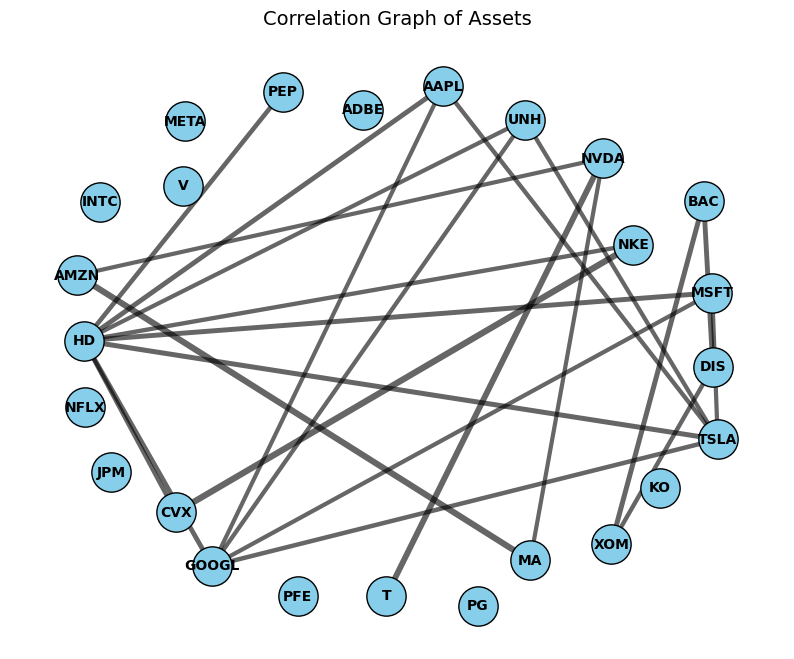


Number of nodes: 25, edges: 23


In [62]:
# ===============================
# 2) Build correlation graph
# ===============================
threshold = 0.6
G = nx.Graph()
G.add_nodes_from(assets)

for i in range(len(assets)):
    for j in range(i + 1, len(assets)):
        w = abs(corr_matrix.iloc[i, j])
        if w > threshold:
            G.add_edge(assets[i], assets[j], weight=w)

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, seed=42, weight='weight', k=5)
edges = G.edges(data=True)
weights = [d['weight'] * 5 for (_, _, d) in edges]

nx.draw_networkx_nodes(G, pos, node_size=800, node_color="skyblue", edgecolors='k')
nx.draw_networkx_edges(G, pos, width=weights, alpha=0.6)
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')
plt.title("Correlation Graph of Assets", fontsize=14)
plt.axis("off")
plt.show()

print(f"\nNumber of nodes: {len(G.nodes())}, edges: {len(G.edges())}")

Detected 13 communities.
Community 2: ['AAPL', 'MSFT', 'GOOGL', 'TSLA', 'UNH', 'HD', 'PEP']
Community 9: ['AMZN', 'NVDA', 'MA', 'T']
Community 5: ['META']
Community 7: ['JPM']
Community 8: ['V']
Community 10: ['XOM', 'BAC', 'DIS']
Community 11: ['CVX', 'NKE']
Community 0: ['PG']
Community 1: ['KO']
Community 3: ['PFE']
Community 4: ['NFLX']
Community 6: ['INTC']
Community 12: ['ADBE']


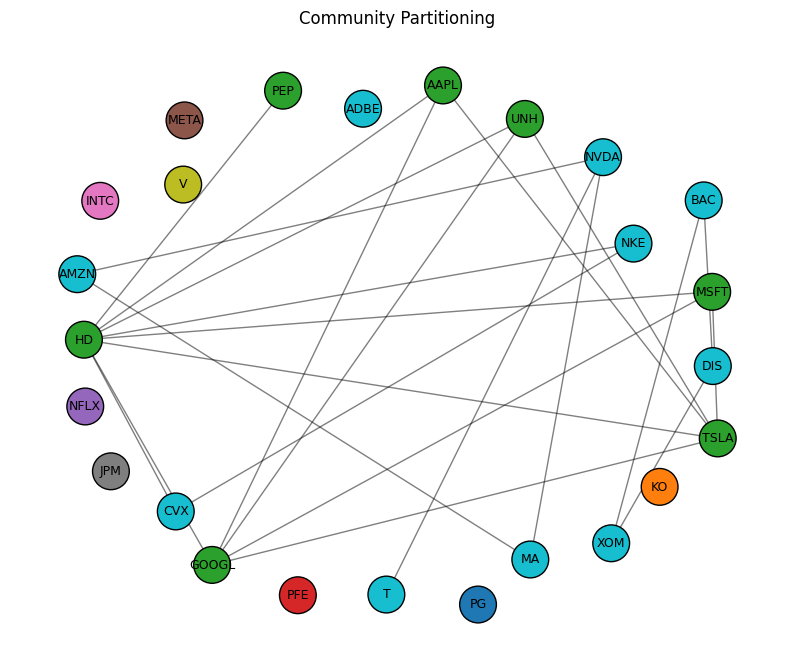

In [63]:
# ===============================
# 3) Community Detection
# ===============================
import community as community_louvain
import matplotlib.cm as cm

community_method = "louvain"  # or "spectral"
if community_method == "louvain":
    partition = community_louvain.best_partition(G)
else:
    from networkx.algorithms import community as nx_comm
    comms = list(nx_comm.spectral_clustering(G, k=min(4, len(G))))
    partition = {node: comms[i] for i, node in enumerate(G.nodes())}

# Organize into dict of communities
communities = {}
for node, cid in partition.items():
    communities.setdefault(cid, []).append(node)

print(f"Detected {len(communities)} communities.")
for cid, nodelist in communities.items():
    print(f"Community {cid}: {nodelist}")

# Visualize
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, seed=42, weight='weight', k=5)
cmap = plt.colormaps.get_cmap("tab10")
nx.draw_networkx_nodes(G, pos,
                       node_color=[cmap(partition[n]) for n in G.nodes()],
                       node_size=700, edgecolors='k')
nx.draw_networkx_edges(G, pos, alpha=0.5)
nx.draw_networkx_labels(G, pos, font_size=9)
plt.title("Community Partitioning")
plt.axis("off")
plt.show()

In [64]:
# ===============================
# 4) QAOA control parameters
# ===============================
A = 4.0
B = 6.0
p = 2                     # max QAOA depth
qaoa_max_n = 12           # max qubits per subproblem
n_restarts = 3
layerwise_training = True
seed = 42

print(f"QAOA max nodes per community: {qaoa_max_n}")

QAOA max nodes per community: 12


In [65]:
# ===============================
# 5) Preprocessing each community
# ===============================
def greedy_preselect(G_sub, k=12):
    """Greedy selection using degree + clustering."""
    metrics = {}
    deg_c = nx.degree_centrality(G_sub)
    clus_c = nx.clustering(G_sub)
    for n in G_sub.nodes():
        metrics[n] = deg_c[n] + clus_c[n]
    top_nodes = sorted(metrics, key=metrics.get, reverse=True)[:k]
    return G_sub.subgraph(top_nodes).copy()

community_results = {}

for cid, nodes_c in communities.items():
    G_sub = G.subgraph(nodes_c).copy()
    if len(G_sub) <= qaoa_max_n:
        community_results[cid] = {"graph": G_sub, "method": "direct"}
        print(f"Community {cid}: {len(G_sub)} nodes → QAOA directly.")
    else:
        G_red = greedy_preselect(G_sub, k=qaoa_max_n)
        community_results[cid] = {"graph": G_red, "method": "reduced"}
        print(f"Community {cid}: reduced from {len(G_sub)}→{len(G_red)} nodes.")

Community 2: 7 nodes → QAOA directly.
Community 9: 4 nodes → QAOA directly.
Community 5: 1 nodes → QAOA directly.
Community 7: 1 nodes → QAOA directly.
Community 8: 1 nodes → QAOA directly.
Community 10: 3 nodes → QAOA directly.
Community 11: 2 nodes → QAOA directly.
Community 0: 1 nodes → QAOA directly.
Community 1: 1 nodes → QAOA directly.
Community 3: 1 nodes → QAOA directly.
Community 4: 1 nodes → QAOA directly.
Community 6: 1 nodes → QAOA directly.
Community 12: 1 nodes → QAOA directly.


In [66]:
# ===============================
# 6) QAOA Runner (corrected)
# ===============================
def run_qaoa_on_subgraph(G_sub, A=4.0, B=2.0, p_max=1, restarts=3, warm_start=None,
                         opt_steps=100, seed_local=42):
    """Runs QAOA on a subgraph with given depth p_max."""
    p = int(p_max)
    nodes = list(G_sub.nodes())
    n = len(nodes)
    if n == 0:
        return np.array([]), np.inf

    G_comp = nx.complement(G_sub)
    Q = np.zeros((n, n))
    for i in range(n):
        Q[i, i] = -A
    for i in range(n):
        for j in range(i + 1, n):
            if G_comp.has_edge(nodes[i], nodes[j]):
                Q[i, j] = Q[j, i] = B

    row_sums = Q.sum(axis=1)
    h = np.zeros(n)
    J = np.zeros((n, n))
    for i in range(n):
        h[i] = -0.5 * Q[i, i] - 0.25 * (row_sums[i] - Q[i, i])
        for j in range(i + 1, n):
            J[i, j] = J[j, i] = 0.25 * Q[i, j]

    coeffs, obs = [], []
    for i in range(n):
        coeffs.append(h[i])
        obs.append(qml.PauliZ(i))
    for i in range(n):
        for j in range(i + 1, n):
            if abs(J[i, j]) > 1e-12:
                coeffs.append(J[i, j])
                obs.append(qml.PauliZ(i) @ qml.PauliZ(j))
    H = qml.Hamiltonian(coeffs, obs)

    dev = qml.device("default.qubit", wires=n)

    @qml.qnode(dev, interface="autograd")
    def circuit(params):
        gammas = params[:p]
        betas = params[p:2*p]
        for i in range(n):
            qml.Hadamard(wires=i)
        for layer in range(p):
            for i in range(n):
                qml.RZ(2.0 * h[i] * gammas[layer], wires=i)
            for i in range(n):
                for j in range(i + 1, n):
                    if abs(J[i, j]) > 1e-12:
                        qml.IsingZZ(2.0 * J[i, j] * gammas[layer], wires=[i, j])
            for i in range(n):
                qml.RX(2.0 * betas[layer], wires=i)
        return qml.expval(H)

    rng = np.random.default_rng(seed_local)
    best_params, best_energy = None, np.inf
    param_len = 2 * p

    for r in range(restarts):
        params = rng.uniform(0.0, 0.1, size=(param_len,))
        if warm_start is not None:
            ws = np.array(warm_start).ravel()
            ncopy = min(len(ws), param_len)
            params[:ncopy] = ws[:ncopy]
        opt = qml.AdamOptimizer(stepsize=0.01)
        for _ in range(opt_steps):
            params, cost = opt.step_and_cost(circuit, params)
        final_e = float(circuit(params))
        if final_e < best_energy:
            best_energy, best_params = final_e, params.copy()

    return np.array(best_params), float(best_energy)


In [67]:
# ===============================
# 7) Layerwise QAOA per community
# ===============================
community_solutions = {}

for cid, entry in community_results.items():
    G_sub = entry["graph"]
    print(f"\n--- Community {cid}: {len(G_sub)} nodes ---")
    print(f"Nodes: {list(G_sub.nodes())}\n{'-'*60}")
    warm_params = None
    progress_layers = []
    for p_layer in range(1, p + 1):
        print(f"  Layer depth p={p_layer}")
        params, energy = run_qaoa_on_subgraph(G_sub,
                                              A=A, B=B,
                                              p_max=p_layer,
                                              restarts=n_restarts,
                                              warm_start=warm_params,
                                              opt_steps=80,
                                              seed_local=seed)
        warm_params = params.copy()
        best_bs = sample_best_bitstring_for_subgraph(G_sub, params, p_layer=p_layer, shots_sample=1000)
        if best_bs != "":
            selected_nodes = [n for n, b in zip(G_sub.nodes(), best_bs) if b == "1"]
        else:
            selected_nodes = []

        progress_layers.append({
            "layer": p_layer,
            "energy": energy,
            "bitstring": best_bs,
            "selected": selected_nodes
        })

        print(f"  Energy: {energy:.6f}")
        print(f"  Bitstring: {best_bs}")
        print(f"  Selected nodes: {selected_nodes}")
        print("-"*60)
    community_solutions[cid] = {"params": warm_params, "energy": energy}


--- Community 2: 7 nodes ---
Nodes: ['UNH', 'TSLA', 'PEP', 'AAPL', 'MSFT', 'HD', 'GOOGL']
------------------------------------------------------------
  Layer depth p=1
  Energy: -6.906290
  Bitstring: 0100111
  Selected nodes: ['TSLA', 'MSFT', 'HD', 'GOOGL']
------------------------------------------------------------
  Layer depth p=2
  Energy: -8.780582
  Bitstring: 0100111
  Selected nodes: ['TSLA', 'MSFT', 'HD', 'GOOGL']
------------------------------------------------------------

--- Community 9: 4 nodes ---
Nodes: ['AMZN', 'NVDA', 'MA', 'T']
------------------------------------------------------------
  Layer depth p=1
  Energy: -3.740448
  Bitstring: 1110
  Selected nodes: ['AMZN', 'NVDA', 'MA']
------------------------------------------------------------
  Layer depth p=2
  Energy: -4.611998
  Bitstring: 1110
  Selected nodes: ['AMZN', 'NVDA', 'MA']
------------------------------------------------------------

--- Community 5: 1 nodes ---
Nodes: ['META']
--------------------

In [68]:
# ===============================
# 8) Robust Sampling Helper
# ===============================
# --------------------------------------
# Fixed sample_best_bitstring_for_subgraph
# --------------------------------------
def sample_best_bitstring_for_subgraph(G_sub, params, p_layer=None, shots_sample=1000, seed_local=123):
    """Return most frequent bitstring (string like '0101') from sampling the prepared QAOA state.
    Handles param==None or empty. Uses 'params' length to infer p if p_layer not provided.
    """
    if params is None:
        return ""
    params = np.array(params).ravel()
    if params.size == 0:
        return ""

    if p_layer is None:
        p_layer = params.size // 2
    p = int(p_layer)
    if p <= 0:
        return ""

    nodes = list(G_sub.nodes())
    n = len(nodes)
    if n == 0:
        return ""

    # build h,J same as in run_qaoa_on_subgraph
    G_comp = nx.complement(G_sub)
    Q = np.zeros((n, n))
    for i in range(n):
        Q[i, i] = -A
    for i in range(n):
        for j in range(i + 1, n):
            if G_comp.has_edge(nodes[i], nodes[j]):
                Q[i, j] = Q[j, i] = B
    row_sums = Q.sum(axis=1)
    h = np.zeros(n)
    J = np.zeros((n, n))
    for i in range(n):
        h[i] = -0.5 * Q[i, i] - 0.25 * (row_sums[i] - Q[i, i])
        for j in range(i + 1, n):
            J[i, j] = J[j, i] = 0.25 * Q[i, j]

    dev_s = qml.device("default.qubit", wires=n, shots=shots_sample)

    @qml.qnode(dev_s)
    def sample_qnode(params_sample):
        params_sample = np.array(params_sample).ravel()
        if params_sample.size < 2 * p:
            params_sample = np.concatenate([params_sample, np.zeros(2 * p - params_sample.size)])
        gammas = params_sample[:p]
        betas = params_sample[p:2*p]

        for i in range(n):
            qml.Hadamard(wires=i)
        for layer in range(p):
            for i in range(n):
                qml.RZ(2.0 * h[i] * float(gammas[layer]), wires=i)
            for i in range(n):
                for j in range(i + 1, n):
                    if abs(J[i, j]) > 1e-12:
                        qml.IsingZZ(2.0 * float(J[i, j]) * float(gammas[layer]), wires=[i, j])
            for i in range(n):
                qml.RX(2.0 * float(betas[layer]), wires=i)
        # return samples as shape (shots, n)
        return qml.sample(wires=range(n))

    samples_raw = np.array(sample_qnode(params))
    if samples_raw.size == 0:
        return ""

    # Ensure samples is 2D: (shots, n)
    if samples_raw.ndim == 1:
        # single-shot returned as length-n array -> make (1,n)
        if samples_raw.size == n:
            samples = samples_raw.reshape(1, n)
        else:
            # fallback (shouldn't happen)
            samples = samples_raw.reshape(-1, n)
    else:
        samples = samples_raw

    # convert each shot to bitstring matching node order
    bitstrings = []
    for s in samples:
        # s elements can be 0/1 or floats; ensure ints
        bits = [str(int(round(float(b)))) for b in s]
        bitstrings.append("".join(bits))

    uniq, cnts = np.unique(bitstrings, return_counts=True)
    best = uniq[np.argmax(cnts)]
    return best

Community 2 best selected nodes: ['TSLA', 'AAPL', 'HD', 'GOOGL']
Community 9 best selected nodes: ['AMZN', 'NVDA', 'MA']
Community 5 best selected nodes: ['META']
Community 7 best selected nodes: ['JPM']
Community 8 best selected nodes: ['V']
Community 10 best selected nodes: ['XOM', 'BAC', 'DIS']
Community 11 best selected nodes: ['NKE', 'CVX']
Community 0 best selected nodes: ['PG']
Community 1 best selected nodes: ['KO']
Community 3 best selected nodes: ['PFE']
Community 4 best selected nodes: ['NFLX']
Community 6 best selected nodes: ['INTC']
Community 12 best selected nodes: ['ADBE']

✅ Largest connected clique-like subset: {'AAPL', 'HD', 'TSLA', 'GOOGL'}


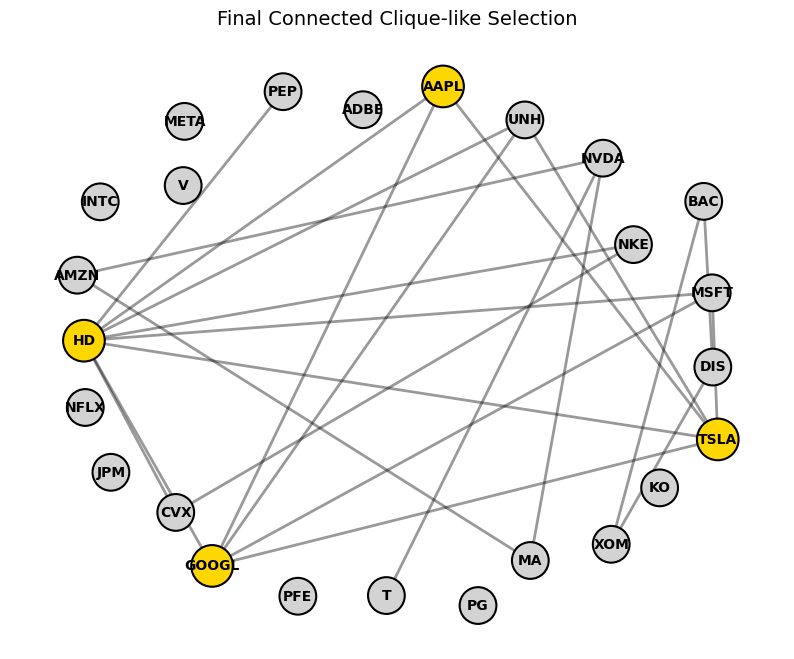

In [69]:
# ===============================
# Final Visualization (connected component filtering)
# ===============================

# Collect selections per community
selected_by_community = {}
for cid, entry in community_results.items():
    G_sub = entry["graph"]
    params = community_solutions.get(cid, {}).get("params", None)
    best_bs = sample_best_bitstring_for_subgraph(G_sub, params, p_layer=len(params)//2, shots_sample=1000)
    if best_bs == "":
        continue
    selected = [n for n, b in zip(G_sub.nodes(), best_bs) if b == "1"]
    selected_by_community[cid] = selected
    print(f"Community {cid} best selected nodes: {selected}")

# Identify largest selection
largest_cid = max(selected_by_community, key=lambda k: len(selected_by_community[k]))
largest_selection = selected_by_community[largest_cid]

# Filter: only keep connected subset (within original graph)
G_largest = G.subgraph(largest_selection)
connected_components = list(nx.connected_components(G_largest))

if not connected_components:
    final_selection = largest_selection
else:
    final_selection = max(connected_components, key=len)

print(f"\n✅ Largest connected clique-like subset: {final_selection}")

# Visualization
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, seed=42, weight='weight', k=5)

node_colors = [
    "gold" if node in final_selection else "lightgray"
    for node in G.nodes()
]
node_sizes = [900 if node in final_selection else 700 for node in G.nodes()]

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, edgecolors='k', linewidths=1.5)
nx.draw_networkx_edges(G, pos, width=2, alpha=0.4)
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

plt.title("Final Connected Clique-like Selection", fontsize=14)
plt.axis("off")
plt.show()
